In [55]:
from diffrax import diffeqsolve, ODETerm
from jax.scipy.stats import norm,poisson
import diffrax
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt
import pandas as pd

from time import perf_counter
from algorithms.nuts import nuts
from utilities.helpers import effective_sample_size,autocorr_new

jax.config.update('jax_platform_name', 'cpu')

print(jax.devices())


[CpuDevice(id=0)]


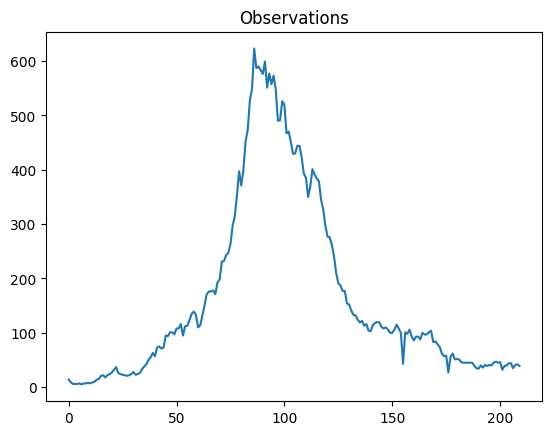

In [56]:
df = pd.read_csv('../datasets/AZ_DATA.csv',index_col=False)

observations = df['total_patients_hospitalized_confirmed_influenza'].to_numpy()
t_range = jnp.arange(0,len(observations))

plt.title('Observations')
plt.plot(t_range, observations)
plt.show()

In [57]:
def rhs(t,state,args):
    S,I,R = state
    N = S + I + R

    beta,gamma = args

    beta = jnp.exp(beta)
    gamma = jnp.exp(gamma)

    dS = -beta * S * I/N
    dI = beta * S * I/N - gamma * I
    dR = gamma * I

    return jnp.array([dS,dI,dR])

In [58]:
'''The model integrator. Takes the length of time to integrate, the initial condition, and a parameter vector.'''
def model(ts,y0,par):
  solution = diffrax.diffeqsolve(
            ODETerm(rhs),
            diffrax.Euler(),
            t0=ts[0],
            t1=ts[-1],
            dt0=ts[1] - ts[0],
            y0=y0,
            args=par,
            saveat=diffrax.SaveAt(ts=ts) #At which points to save the output
        )
  return solution.ys

In [59]:
def log_likelihood(par):
    beta, gamma, rho, i0 = par

    rho = jax.nn.sigmoid(rho)
    i0 = jax.nn.sigmoid(i0)
    IC = 7_600_000 * jnp.array([1.0 - i0, i0, 0.0])

    model_output = jnp.maximum(model(t_range, IC, (beta, gamma)), 1e-6)
    return jnp.sum(
        jax.scipy.stats.norm.logpdf(observations, rho * model_output[:, 1], 200)
    )


def prior(par):
    beta, gamma, rho, i0 = par
    return (
        jax.scipy.stats.norm.logpdf(beta, jnp.log(0.3), 0.3)
        + jax.scipy.stats.norm.logpdf(gamma, jnp.log(1 / 5), 0.3)
        + jax.scipy.stats.norm.logpdf(rho, jnp.log(150 / 100_000), 0.1)
        + jax.scipy.stats.norm.logpdf(i0, jnp.log(0.01), 1.0)
    )


def joint(par):
    return log_likelihood(par) + prior(par)

In [60]:
func = jax.jit(jax.value_and_grad(joint))

D = 4
M = 1_000
Madapt = 1000
key = jax.random.key(0)
init_key, key = jax.random.split(key)

theta0 = jax.random.multivariate_normal(
    init_key,
    mean=jnp.log(jnp.array([0.3, 1 / 5, 150 / 100_000, 0.01])),
    cov=0.1 * jnp.eye(D),
    shape=(),
)

nuts_key, key = jax.random.split(key)
t0 = perf_counter()
samples, lnprob = nuts(
    func, M, Madapt, theta0, key=nuts_key, epsilon=0.01, max_depth=7
)
t1 = perf_counter()
print(f"Done. runtime {t1 - t0} seconds")
print(f"Effective sample size: {effective_sample_size(samples)}")
print(f"Integrated autocorrelation: {autocorr_new(samples)}")

Done. runtime 294.65016196796205 seconds
Effective sample size: [ 79.64287  118.42448  511.11005   49.289715]
Integrated autocorrelation: [12.556052   8.4442005  1.9565258 20.288208 ]


/tmp/ipykernel_1791623/2169550422.py:25: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


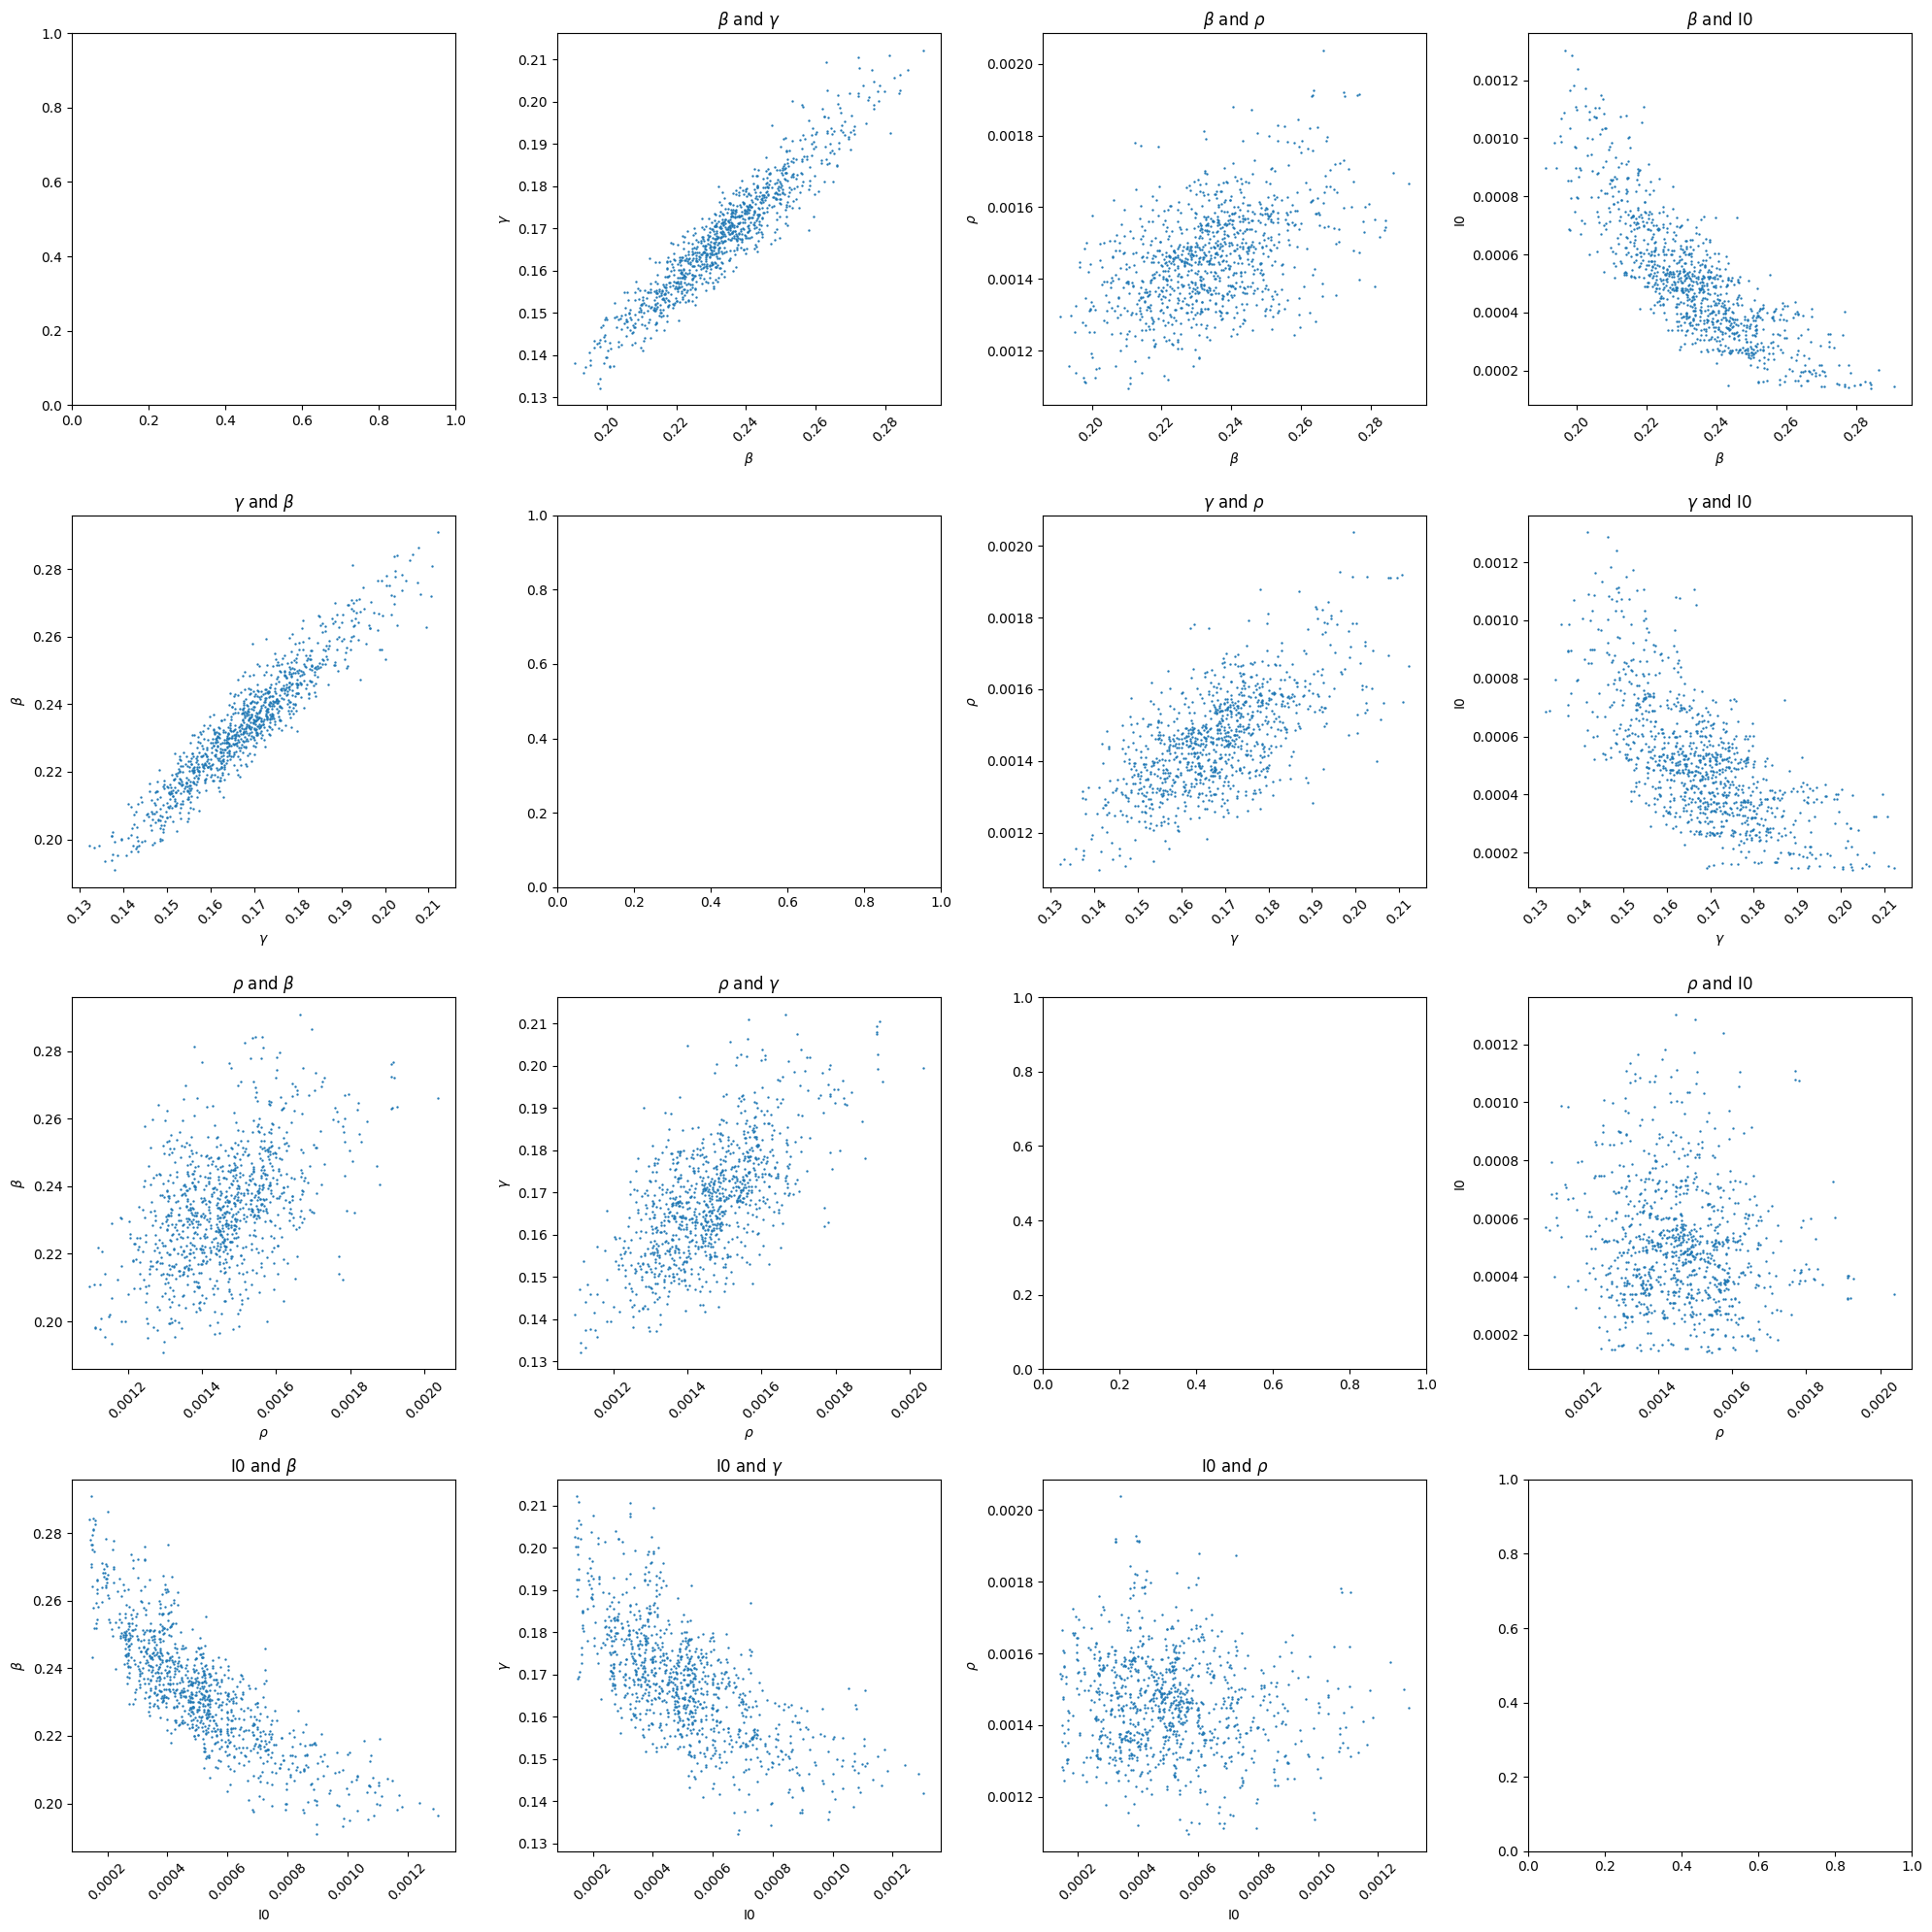

In [61]:
fig, axes = plt.subplots(D, D, figsize=(5*D, 5*D),layout="constrained")

plot_samples = jnp.exp(samples).squeeze()

par_names = ["$\\beta$","$\\gamma$","$\\rho$","I0"]

for par1_index in range(D):
    for par2_index in range(D):

        if par1_index != par2_index: 
            axes[par1_index, par2_index].set_title(
                f"{par_names[par1_index]} and {par_names[par2_index]}"
            )
            axes[par1_index, par2_index].scatter(
                plot_samples[:, par1_index],
                plot_samples[:, par2_index],
                s = 0.5
            )

            axes[par1_index, par2_index].tick_params(axis='x', labelrotation=45)

            axes[par1_index, par2_index].set_xlabel(f"{par_names[par1_index]}")
            axes[par1_index, par2_index].set_ylabel(f"{par_names[par2_index]}")

fig.tight_layout()
plt.show()


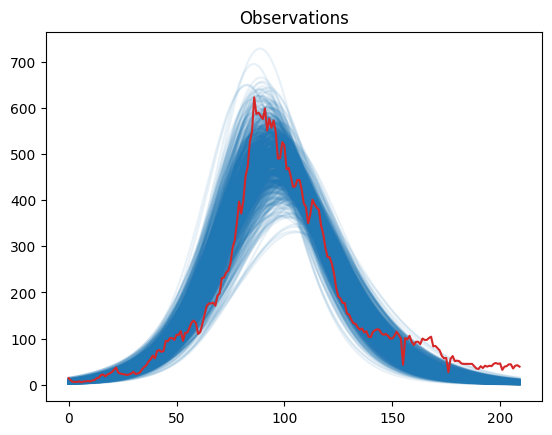

In [62]:
flat_samples = samples.squeeze()
IC = jnp.zeros((len(flat_samples), 3))

samples_I0 = jax.nn.sigmoid(flat_samples[:, -1])
samples_rho = jax.nn.sigmoid(flat_samples[:, -2])

samples_betagamma = flat_samples[:, :-2]

IC = IC.at[:, 0].set(1.0 - samples_I0)
IC = IC.at[:, 1].set(samples_I0)
IC = IC.at[:, 2].set(0.0)
IC = IC * 7_600_000


model_output = jax.vmap(model, in_axes=(None, 0, 0))(t_range, IC,samples_betagamma)

plt.title("Observations")
plt.plot(t_range, observations, color="tab:red", zorder=100)
plt.plot(
    t_range,
    samples_rho * model_output[:, :, 1].T,
    alpha=0.1,
    color="tab:blue",
)
plt.show()